Data Analyzing 

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("Data/garments_worker_productivity.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [2]:
missing_summary = pd.DataFrame({
    "missing_count":df.isna().sum(),
    "missing_percent":df.isna().mean()*100
})
display(
    missing_summary.sort_values("missing_count", ascending=False)
)
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_percent
wip,506,42.272348
quarter,0,0.000000
date,0,0.000000
day,0,0.000000
team,0,0.000000
targeted_productivity,0,0.000000
department,0,0.000000
smv,0,0.000000
over_time,0,0.000000
incentive,0,0.000000


Duplicate rows: 0


In [3]:
df[["targeted_productivity", "actual_productivity"]].describe()

,targeted_productivity,actual_productivity
count,1197.000000,1197.000000
mean,0.729632,0.735091
std,0.097891,0.174488
min,0.070000,0.233705
25%,0.700000,0.650307
50%,0.750000,0.773333
75%,0.800000,0.850253
max,0.800000,1.120437


In [4]:
# repr makes extra spaces in category labels visible
print(df["department"].apply(repr).unique())

# Check whether wip missingness varies by department
wip_summary = (
    df.assign(wip_missing=df["wip"].isna())
    .groupby("department")["wip_missing"]
    .agg(["size", "sum", "mean"])
)

wip_summary.columns = [
    "total_rows",
    "missing_wip",
    "missing_percent"
]

wip_summary["missing_percent"] *= 100

display(wip_summary)

<ArrowStringArray>
[''sweing'', ''finishing '', ''finishing'']
Length: 3, dtype: str


,total_rows,missing_wip,missing_percent
department,,,
finishing,249,249,100.0
finishing,257,257,100.0
sweing,691,0,0.0


In [5]:
meets_target = (
    df["actual_productivity"] >= df["targeted_productivity"]
)

print("Percentage meeting target:", meets_target.mean() * 100)
print(meets_target.value_counts())
display(
    df.nsmallest(5, "targeted_productivity")
)

display(
    df[df["actual_productivity"] > 1]
)

Percentage meeting target: 73.09941520467837
True     875
False    322
Name: count, dtype: int64


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
633,2/5/2015,Quarter1,sweing,Thursday,7,0.07,24.26,1608.0,6960,0,0.0,0,0,58.0,0.522845
146,1/8/2015,Quarter2,sweing,Thursday,11,0.35,12.52,287.0,25920,38,0.0,0,0,54.0,0.349951
194,1/12/2015,Quarter2,finishing,Monday,4,0.35,4.30,NaN,3240,0,0.0,0,0,18.0,0.942214
214,1/12/2015,Quarter2,sweing,Monday,4,0.35,22.40,581.0,7350,0,0.0,0,0,51.5,0.350633
216,1/13/2015,Quarter2,finishing,Tuesday,4,0.35,4.30,NaN,2160,0,0.0,0,0,12.0,0.952020


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,1/20/2015,Quarter3,finishing,Tuesday,5,0.70,4.15,NaN,1440,0,0.0,0,0,8.0,1.033570
437,1/26/2015,Quarter4,finishing,Monday,3,0.75,3.94,NaN,1800,0,0.0,0,0,10.0,1.059621
456,1/27/2015,Quarter4,sweing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,1/27/2015,Quarter4,sweing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,1/28/2015,Quarter4,sweing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,1/28/2015,Quarter4,sweing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,1/29/2015,Quarter5,sweing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,1/31/2015,Quarter5,sweing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,1/31/2015,Quarter5,sweing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2/1/2015,Quarter1,finishing,Sunday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,1.011562


In [6]:
# Work on a copy
data = df.copy()

# Remove extra spaces from department labels
data["department"] = data["department"].str.strip()

# Regression target
y_reg = data["actual_productivity"].copy()

# Classification target
y_clf = (
    data["actual_productivity"] >= data["targeted_productivity"]
).astype(int)

# Candidate inputs shared by both models
# Exclude the actual outcome to prevent target leakage
X = data.drop(columns=["actual_productivity"])

print("Input shape:", X.shape)
print("\nClassification counts:")
print(y_clf.value_counts())

print("\nInput data types:")
print(X.dtypes)

Input shape: (1197, 14)

Classification counts:
1    875
0    322
Name: count, dtype: int64

Input data types:
date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
dtype: object


In [7]:
X = X.copy()

# Parse dates explicitly: month/day/year
parsed_date = pd.to_datetime(X["date"], format="%m/%d/%Y")

# Use month as a categorical calendar feature
X["month"] = parsed_date.dt.month.astype(str)

# Remove the original date string
X = X.drop(columns=["date"])

# Team numbers identify groups, rather than measured quantities
X["team"] = X["team"].astype(str)

categorical_cols = [
    "quarter",
    "department",
    "day",
    "team",
    "month"
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("Input shape:", X.shape)

Categorical columns: ['quarter', 'department', 'day', 'team', 'month']
Numerical columns: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']
Input shape: (1197, 14)


In [8]:
from sklearn.model_selection import train_test_split

# Positions of all observations
row_positions = np.arange(len(X))

# One fixed 80:20 split, preserving classification proportions
train_idx, test_idx = train_test_split(
    row_positions,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

# Same input rows for both tasks
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

# Regression targets
y_reg_train = y_reg.iloc[train_idx].copy()
y_reg_test = y_reg.iloc[test_idx].copy()

# Classification targets
y_clf_train = y_clf.iloc[train_idx].copy()
y_clf_test = y_clf.iloc[test_idx].copy()

# Save positions for the manual implementation
# Reuse with the same dataset row order
np.savez(
    "split_indices.npz",
    train_idx=train_idx,
    test_idx=test_idx
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class percentages:")
print(y_clf_train.value_counts(normalize=True).sort_index() * 100)

print("\nTest class percentages:")
print(y_clf_test.value_counts(normalize=True).sort_index() * 100)

Training shape: (957, 14)
Test shape: (240, 14)

Training class percentages:
0    26.854754
1    73.145246
Name: proportion, dtype: float64

Test class percentages:
0    27.083333
1    72.916667
Name: proportion, dtype: float64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical: fill missing values, then scale
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: one-hot encode with one reference category dropped
categorical_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# Apply the appropriate treatment to each column
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_cols),
    ("categorical", categorical_encoder, categorical_cols)
])

# Learn preprocessing rules from training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply those same rules to test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

print("Training contains missing values:",
      np.isnan(X_train_processed).any())

print("Test contains missing values:",
      np.isnan(X_test_processed).any())

Processed training shape: (957, 32)
Processed test shape: (240, 32)
Training contains missing values: False
Test contains missing values: False


In [10]:
imputer = preprocessor.named_transformers_["numerical"].named_steps["imputer"]

wip_position = numerical_cols.index("wip")
print("Training median used for wip:", imputer.statistics_[wip_position])

Training median used for wip: 1038.0


In [11]:
from time import perf_counter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()

# Training time: learning the coefficients
start = perf_counter()
lr_model.fit(X_train_processed, y_reg_train)
lr_train_time = perf_counter() - start

# Prediction time: using the learned coefficients
start = perf_counter()
y_reg_pred = lr_model.predict(X_test_processed)
lr_predict_time = perf_counter() - start

# Evaluation is outside the timed sections
lr_mae = mean_absolute_error(y_reg_test, y_reg_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
lr_r2 = r2_score(y_reg_test, y_reg_pred)

print(f"MAE:             {lr_mae:.6f}")
print(f"RMSE:            {lr_rmse:.6f}")
print(f"R²:              {lr_r2:.6f}")
print(f"Training time:   {lr_train_time * 1000:.3f} ms")
print(f"Prediction time: {lr_predict_time * 1000:.3f} ms")

MAE:             0.108565
RMSE:            0.142306
R²:              0.302654
Training time:   13.755 ms
Prediction time: 0.628 ms


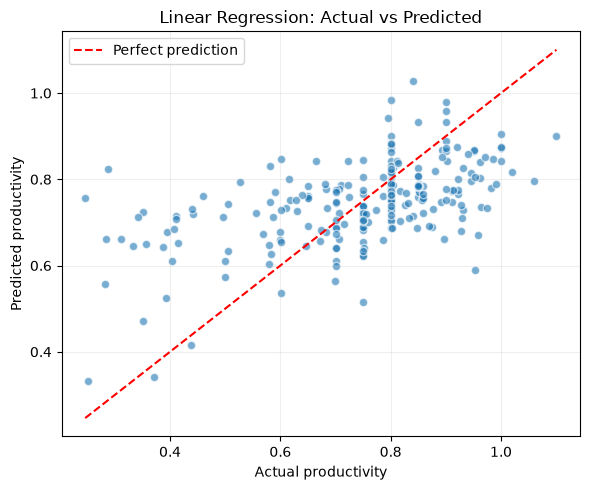

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.6,
    edgecolors="white"
)

# Perfect predictions lie on this diagonal
lower = min(y_reg_test.min(), y_reg_pred.min())
upper = max(y_reg_test.max(), y_reg_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual productivity")
plt.ylabel("Predicted productivity")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

log_model = LogisticRegression(max_iter=2000)

# Training
start = perf_counter()
log_model.fit(X_train_processed, y_clf_train)
log_train_time = perf_counter() - start

# Predict class labels
start = perf_counter()
y_clf_pred = log_model.predict(X_test_processed)
log_predict_time = perf_counter() - start

# Evaluate outside the timed sections
log_accuracy = accuracy_score(y_clf_test, y_clf_pred)
log_precision = precision_score(y_clf_test, y_clf_pred, zero_division=0)
log_recall = recall_score(y_clf_test, y_clf_pred, zero_division=0)
log_f1 = f1_score(y_clf_test, y_clf_pred, zero_division=0)

print(f"Accuracy:        {log_accuracy:.6f}")
print(f"Precision:       {log_precision:.6f}")
print(f"Recall:          {log_recall:.6f}")
print(f"F1-score:        {log_f1:.6f}")
print(f"Training time:   {log_train_time * 1000:.3f} ms")
print(f"Prediction time: {log_predict_time * 1000:.3f} ms")

print("\nConfusion matrix (rows=actual, columns=predicted):")
print(confusion_matrix(y_clf_test, y_clf_pred, labels=[0, 1]))

Accuracy:        0.687500
Precision:       0.763158
Recall:          0.828571
F1-score:        0.794521
Training time:   21.126 ms
Prediction time: 0.472 ms

Confusion matrix (rows=actual, columns=predicted):
[[ 20  45]
 [ 30 145]]


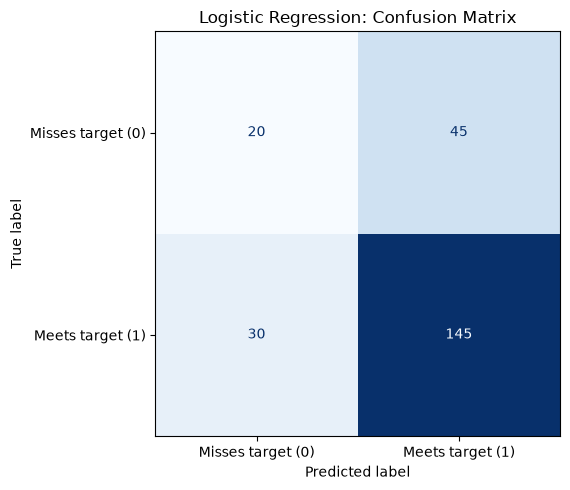

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_clf_test,
    y_clf_pred,
    labels=[0, 1]
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Misses target (0)", "Meets target (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))

display_cm.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.show()

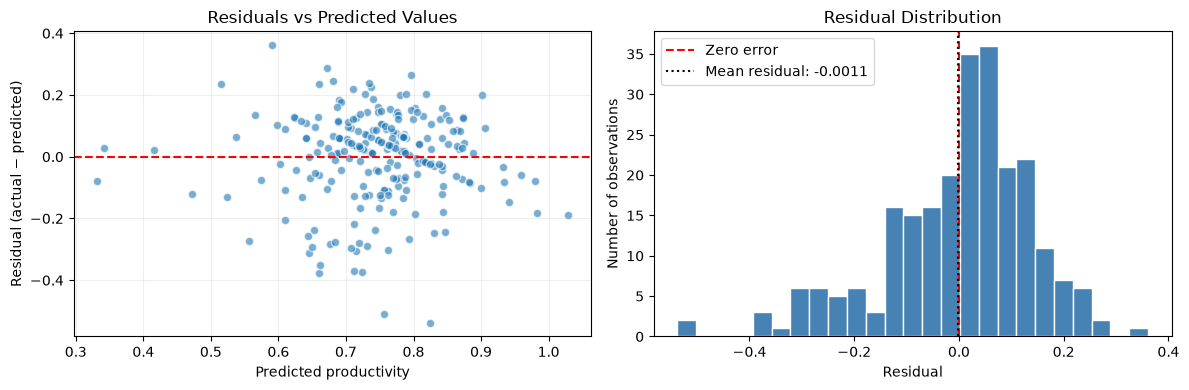

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Residual = actual value - predicted value
residuals = np.asarray(y_reg_test) - y_reg_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals against predictions
axes[0].scatter(
    y_reg_pred,
    residuals,
    alpha=0.6,
    edgecolors="white"
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted productivity")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].grid(alpha=0.2)

# Distribution of residuals
axes[1].hist(
    residuals,
    bins=25,
    color="steelblue",
    edgecolor="white"
)
axes[1].axvline(
    0,
    color="red",
    linestyle="--",
    label="Zero error"
)
axes[1].axvline(
    residuals.mean(),
    color="black",
    linestyle=":",
    label=f"Mean residual: {residuals.mean():.4f}"
)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Number of observations")
axes[1].set_title("Residual Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part B — From-Scratch Implementation
### 1. Load Data and Reuse the Fixed Train-Test Split

In [16]:
# Part B: Manual numerical preprocessing

# Use the same training and test samples from Part A
num_train = X_train[numerical_cols].copy()
num_test = X_test[numerical_cols].copy()

# Calculate medians using training data only
train_medians = num_train.median()

# Fill missing values
num_train = num_train.fillna(train_medians)
num_test = num_test.fillna(train_medians)

# Calculate scaling statistics from imputed training data
train_means = num_train.mean()
train_stds = num_train.std(ddof=0).replace(0, 1)

# Manually standardize both datasets
num_train_scaled = (
    (num_train - train_means) / train_stds
).to_numpy(dtype=float)

num_test_scaled = (
    (num_test - train_means) / train_stds
).to_numpy(dtype=float)

print("Training median for wip:", train_medians["wip"])

print("\nNumerical training shape:", num_train_scaled.shape)
print("Numerical test shape:", num_test_scaled.shape)

print("\nTraining contains missing values:",
      np.isnan(num_train_scaled).any())

print("Test contains missing values:",
      np.isnan(num_test_scaled).any())

Training median for wip: 1038.0

Numerical training shape: (957, 9)
Numerical test shape: (240, 9)

Training contains missing values: False
Test contains missing values: False


In [17]:
# Part B: Manual one-hot encoding

train_encoded_parts = []
test_encoded_parts = []
encoded_feature_names = []
category_mapping = {}

for col in categorical_cols:
    # Learn categories from training data only
    categories = sorted(X_train[col].dropna().unique())
    category_mapping[col] = categories

    # Drop the first category, matching Part A
    for category in categories[1:]:
        train_column = (
            X_train[col] == category
        ).to_numpy(dtype=float)

        test_column = (
            X_test[col] == category
        ).to_numpy(dtype=float)

        train_encoded_parts.append(train_column)
        test_encoded_parts.append(test_column)
        encoded_feature_names.append(f"{col}_{category}")

# Convert encoded columns into matrices
cat_train_encoded = np.column_stack(train_encoded_parts)
cat_test_encoded = np.column_stack(test_encoded_parts)

# Numerical columns first, then categorical columns
X_train_manual = np.column_stack([
    num_train_scaled,
    cat_train_encoded
])

X_test_manual = np.column_stack([
    num_test_scaled,
    cat_test_encoded
])

manual_feature_names = numerical_cols + encoded_feature_names

print("Encoded categorical training shape:", cat_train_encoded.shape)
print("Encoded categorical test shape:", cat_test_encoded.shape)

print("\nFinal training shape:", X_train_manual.shape)
print("Final test shape:", X_test_manual.shape)

print("\nTraining contains missing values:",
      np.isnan(X_train_manual).any())

print("Test contains missing values:",
      np.isnan(X_test_manual).any())

Encoded categorical training shape: (957, 23)
Encoded categorical test shape: (240, 23)

Final training shape: (957, 32)
Final test shape: (240, 32)

Training contains missing values: False
Test contains missing values: False


In [18]:
# Manual Linear Regression using the normal equations
from time import perf_counter

y_train_reg_np = np.asarray(y_reg_train, dtype=float)
y_test_reg_np = np.asarray(y_reg_test, dtype=float)

# Training
start = perf_counter()

# Add intercept column
X_train_bias = np.column_stack([
    np.ones(X_train_manual.shape[0]),
    X_train_manual
])

# Explicit matrix multiplications
XtX = X_train_bias.T @ X_train_bias
Xty = X_train_bias.T @ y_train_reg_np

# Pseudoinverse handles possible dependent columns
manual_lr_weights = np.linalg.pinv(XtX) @ Xty

manual_lr_train_time = perf_counter() - start

# Prediction: matrix multiplication plus intercept
start = perf_counter()

manual_lr_pred = (
    X_test_manual @ manual_lr_weights[1:]
    + manual_lr_weights[0]
)

manual_lr_predict_time = perf_counter() - start

# Manual evaluation
errors = y_test_reg_np - manual_lr_pred

manual_lr_mae = np.mean(np.abs(errors))
manual_lr_rmse = np.sqrt(np.mean(errors ** 2))

ss_res = np.sum(errors ** 2)
ss_total = np.sum((y_test_reg_np - y_test_reg_np.mean()) ** 2)
manual_lr_r2 = 1 - ss_res / ss_total

print(f"MAE:             {manual_lr_mae:.6f}")
print(f"RMSE:            {manual_lr_rmse:.6f}")
print(f"R²:              {manual_lr_r2:.6f}")
print(f"Training time:   {manual_lr_train_time * 1000:.3f} ms")
print(f"Prediction time: {manual_lr_predict_time * 1000:.3f} ms")
normal_equation_results = {
    "MAE": manual_lr_mae,
    "RMSE": manual_lr_rmse,
    "R²": manual_lr_r2,
    "Training time (ms)": manual_lr_train_time * 1000,
    "Prediction time (ms)": manual_lr_predict_time * 1000
}

MAE:             0.108565
RMSE:            0.142306
R²:              0.302654
Training time:   8.876 ms
Prediction time: 0.119 ms


In [19]:
# Part B: Linear Regression from scratch
from time import perf_counter

# Convert targets to NumPy arrays
y_train_reg_np = np.asarray(y_reg_train, dtype=float)
y_test_reg_np = np.asarray(y_reg_test, dtype=float)

# Training: include an intercept column and solve least squares
start = perf_counter()

X_train_bias = np.column_stack([
    np.ones(X_train_manual.shape[0]),
    X_train_manual
])

manual_lr_weights = np.linalg.lstsq(
    X_train_bias,
    y_train_reg_np,
    rcond=None
)[0]

manual_lr_train_time = perf_counter() - start

# Prediction
start = perf_counter()

manual_lr_pred = (
    X_test_manual @ manual_lr_weights[1:]
    + manual_lr_weights[0]
)

manual_lr_predict_time = perf_counter() - start

# Calculate metrics manually, outside the timed sections
errors = y_test_reg_np - manual_lr_pred

manual_lr_mae = np.mean(np.abs(errors))
manual_lr_rmse = np.sqrt(np.mean(errors ** 2))

ss_res = np.sum(errors ** 2)
ss_total = np.sum(
    (y_test_reg_np - np.mean(y_test_reg_np)) ** 2
)

manual_lr_r2 = 1 - (ss_res / ss_total)

print(f"MAE:             {manual_lr_mae:.6f}")
print(f"RMSE:            {manual_lr_rmse:.6f}")
print(f"R²:              {manual_lr_r2:.6f}")
print(f"Training time:   {manual_lr_train_time * 1000:.3f} ms")
print(f"Prediction time: {manual_lr_predict_time * 1000:.3f} ms")
least_squares_results = {
    "MAE": manual_lr_mae,
    "RMSE": manual_lr_rmse,
    "R²": manual_lr_r2,
    "Training time (ms)": manual_lr_train_time * 1000,
    "Prediction time (ms)": manual_lr_predict_time * 1000
}

MAE:             0.108565
RMSE:            0.142306
R²:              0.302654
Training time:   7.149 ms
Prediction time: 0.106 ms


In [20]:
# Part B: Logistic Regression from scratch
# NumPy only; perf_counter is used for timing

def sigmoid(z):
    """Numerically stable sigmoid."""
    result = np.empty_like(z, dtype=float)
    positive = z >= 0

    result[positive] = 1 / (1 + np.exp(-z[positive]))

    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z / (1 + exp_z)

    return result


def fit_logistic_manual(
    X, y, learning_rate=0.1, max_iter=20000,
    tolerance=1e-6, C=1.0
):
    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    intercept = 0.0

    # L2 penalty with C=1, matching Part A's intended baseline
    regularization = 1.0 / (C * n_samples)
    converged = False

    for iteration in range(max_iter):
        probabilities = sigmoid(X @ weights + intercept)
        errors = probabilities - y

        # Gradients: average log loss + L2 penalty
        weight_gradient = (
            X.T @ errors / n_samples
            + regularization * weights
        )
        intercept_gradient = np.mean(errors)

        gradient_size = max(
            np.max(np.abs(weight_gradient)),
            abs(intercept_gradient)
        )

        if gradient_size < tolerance:
            converged = True
            break

        weights -= learning_rate * weight_gradient
        intercept -= learning_rate * intercept_gradient

    return weights, intercept, iteration + 1, converged


y_train_clf_np = np.asarray(y_clf_train, dtype=float)
y_test_clf_np = np.asarray(y_clf_test, dtype=int)

# Training
start = perf_counter()

(
    manual_log_weights,
    manual_log_intercept,
    manual_log_iterations,
    manual_log_converged
) = fit_logistic_manual(X_train_manual, y_train_clf_np)

manual_log_train_time = perf_counter() - start

# Predict probabilities and convert them to class labels
start = perf_counter()

manual_log_prob = sigmoid(
    X_test_manual @ manual_log_weights + manual_log_intercept
)

manual_log_pred = (manual_log_prob > 0.5).astype(int)

manual_log_predict_time = perf_counter() - start

# Manual confusion-matrix counts
tn = np.sum((y_test_clf_np == 0) & (manual_log_pred == 0))
fp = np.sum((y_test_clf_np == 0) & (manual_log_pred == 1))
fn = np.sum((y_test_clf_np == 1) & (manual_log_pred == 0))
tp = np.sum((y_test_clf_np == 1) & (manual_log_pred == 1))

# Manual metrics
manual_log_accuracy = (tp + tn) / len(y_test_clf_np)
manual_log_precision = tp / (tp + fp) if (tp + fp) else 0.0
manual_log_recall = tp / (tp + fn) if (tp + fn) else 0.0
manual_log_f1 = (
    2 * tp / (2 * tp + fp + fn)
    if (2 * tp + fp + fn) else 0.0
)

manual_log_cm = np.array([[tn, fp], [fn, tp]])

print(f"Accuracy:        {manual_log_accuracy:.6f}")
print(f"Precision:       {manual_log_precision:.6f}")
print(f"Recall:          {manual_log_recall:.6f}")
print(f"F1-score:        {manual_log_f1:.6f}")
print(f"Training time:   {manual_log_train_time * 1000:.3f} ms")
print(f"Prediction time: {manual_log_predict_time * 1000:.3f} ms")
print(f"Iterations:      {manual_log_iterations}")
print(f"Converged:       {manual_log_converged}")
print("\nConfusion matrix:")
print(manual_log_cm)

Accuracy:        0.687500
Precision:       0.763158
Recall:          0.828571
F1-score:        0.794521
Training time:   1009.125 ms
Prediction time: 0.141 ms
Iterations:      20000
Converged:       False

Confusion matrix:
[[ 20  45]
 [ 30 145]]


### Baseline Comparison: Scikit-learn vs From-Scratch Implementation

Both implementations used the same training and test samples, input features, target definitions, and evaluation metrics. Manual preprocessing used training medians for missing values, standardization of numerical features, and one-hot encoding of categorical features.


In [21]:
# Part C: Baseline comparison

regression_comparison = pd.DataFrame({
    "Implementation": ["Scikit-learn", "Manual NumPy"],
    "MAE": [lr_mae, manual_lr_mae],
    "RMSE": [lr_rmse, manual_lr_rmse],
    "R²": [lr_r2, manual_lr_r2],
    "Training time (ms)": [
        lr_train_time * 1000,
        manual_lr_train_time * 1000
    ],
    "Prediction time (ms)": [
        lr_predict_time * 1000,
        manual_lr_predict_time * 1000
    ]
}).set_index("Implementation")

classification_comparison = pd.DataFrame({
    "Implementation": ["Scikit-learn", "Manual NumPy"],
    "Accuracy": [log_accuracy, manual_log_accuracy],
    "Precision": [log_precision, manual_log_precision],
    "Recall": [log_recall, manual_log_recall],
    "F1-score": [log_f1, manual_log_f1],
    "Training time (ms)": [
        log_train_time * 1000,
        manual_log_train_time * 1000
    ],
    "Prediction time (ms)": [
        log_predict_time * 1000,
        manual_log_predict_time * 1000
    ]
}).set_index("Implementation")

print("Linear Regression comparison")
display(regression_comparison.round(6))

print("\nLogistic Regression comparison")
display(classification_comparison.round(6))

Linear Regression comparison


,MAE,RMSE,R²,Training time (ms),Prediction time (ms)
Implementation,,,,,
Scikit-learn,0.108565,0.142306,0.302654,13.7546,0.6283
Manual NumPy,0.108565,0.142306,0.302654,7.1489,0.1059



Logistic Regression comparison


,Accuracy,Precision,Recall,F1-score,Training time (ms),Prediction time (ms)
Implementation,,,,,,
Scikit-learn,0.6875,0.763158,0.828571,0.794521,21.1263,0.4716
Manual NumPy,0.6875,0.763158,0.828571,0.794521,1009.1254,0.1406


In [22]:
# Part C: Optimized manual Logistic Regression using Newton's method
# Reuses the stable sigmoid function defined in Part B

def fit_logistic_newton(X, y, C=1.0, max_iter=100, tolerance=1e-6):
    n_samples = X.shape[0]

    # First column corresponds to the intercept
    X_bias = np.column_stack([np.ones(n_samples), X])
    coefficients = np.zeros(X_bias.shape[1])

    # Same L2 regularization as the manual baseline
    penalty = np.full(X_bias.shape[1], 1.0 / (C * n_samples))
    penalty[0] = 0.0  # Do not penalize the intercept

    def objective(beta):
        z = X_bias @ beta

        # Numerically stable binary log loss + L2 penalty
        return (
            np.mean(np.logaddexp(0, z) - y * z)
            + 0.5 * np.sum(penalty * beta**2)
        )

    updates = 0
    status = "Maximum iterations reached"

    for _ in range(max_iter):
        probabilities = sigmoid(X_bias @ coefficients)

        gradient = (
            X_bias.T @ (probabilities - y) / n_samples
            + penalty * coefficients
        )

        if np.max(np.abs(gradient)) < tolerance:
            status = "Converged"
            break

        # Hessian: curvature of the objective
        curvature = probabilities * (1 - probabilities)

        hessian = (
            X_bias.T @ (X_bias * curvature[:, None]) / n_samples
            + np.diag(penalty)
        )

        # Solve for the Newton direction without computing an inverse
        direction = np.linalg.solve(hessian, gradient)

        # Backtracking: reduce the step if necessary
        current_loss = objective(coefficients)
        expected_decrease = gradient @ direction
        step = 1.0
        accepted = False

        for _ in range(40):
            candidate = coefficients - step * direction

            if objective(candidate) <= (
                current_loss - 1e-4 * step * expected_decrease
            ):
                coefficients = candidate
                accepted = True
                updates += 1
                break

            step *= 0.5

        if not accepted:
            status = "Line search stopped"
            break

    # Check the final parameters, including the last update
    final_probabilities = sigmoid(X_bias @ coefficients)
    final_gradient = (
        X_bias.T @ (final_probabilities - y) / n_samples
        + penalty * coefficients
    )

    gradient_norm = np.max(np.abs(final_gradient))
    converged = gradient_norm < tolerance

    if converged:
        status = "Converged"

    return coefficients, updates, converged, gradient_norm, status


# Training
start = perf_counter()

(
    optimized_log_coefficients,
    optimized_log_iterations,
    optimized_log_converged,
    optimized_log_gradient,
    optimized_log_status
) = fit_logistic_newton(X_train_manual, y_train_clf_np)

optimized_log_train_time = perf_counter() - start

# Prediction
start = perf_counter()

optimized_log_prob = sigmoid(
    X_test_manual @ optimized_log_coefficients[1:]
    + optimized_log_coefficients[0]
)

optimized_log_pred = (optimized_log_prob > 0.5).astype(int)

optimized_log_predict_time = perf_counter() - start

# Manual evaluation
opt_tn = np.sum((y_test_clf_np == 0) & (optimized_log_pred == 0))
opt_fp = np.sum((y_test_clf_np == 0) & (optimized_log_pred == 1))
opt_fn = np.sum((y_test_clf_np == 1) & (optimized_log_pred == 0))
opt_tp = np.sum((y_test_clf_np == 1) & (optimized_log_pred == 1))

optimized_log_accuracy = (opt_tp + opt_tn) / len(y_test_clf_np)

optimized_log_precision = (
    opt_tp / (opt_tp + opt_fp) if (opt_tp + opt_fp) else 0.0
)

optimized_log_recall = (
    opt_tp / (opt_tp + opt_fn) if (opt_tp + opt_fn) else 0.0
)

optimized_log_f1 = (
    2 * opt_tp / (2 * opt_tp + opt_fp + opt_fn)
    if (2 * opt_tp + opt_fp + opt_fn) else 0.0
)

print(f"Accuracy:        {optimized_log_accuracy:.6f}")
print(f"Precision:       {optimized_log_precision:.6f}")
print(f"Recall:          {optimized_log_recall:.6f}")
print(f"F1-score:        {optimized_log_f1:.6f}")
print(f"Training time:   {optimized_log_train_time * 1000:.3f} ms")
print(f"Prediction time: {optimized_log_predict_time * 1000:.3f} ms")
print(f"Newton updates:  {optimized_log_iterations}")
print(f"Converged:       {optimized_log_converged}")
print(f"Gradient norm:   {optimized_log_gradient:.3e}")
print(f"Status:          {optimized_log_status}")

print("\nConfusion matrix:")
print(np.array([[opt_tn, opt_fp], [opt_fn, opt_tp]]))

print(
    "\nTraining speedup over manual gradient descent:",
    f"{manual_log_train_time / optimized_log_train_time:.2f}x"
)

Accuracy:        0.687500
Precision:       0.763158
Recall:          0.828571
F1-score:        0.794521
Training time:   3.822 ms
Prediction time: 0.135 ms
Newton updates:  6
Converged:       True
Gradient norm:   1.693e-09
Status:          Converged

Confusion matrix:
[[ 20  45]
 [ 30 145]]

Training speedup over manual gradient descent: 264.00x


In [23]:
# Add the optimized implementation to the classification table
classification_comparison.loc["Manual NumPy — Newton"] = {
    "Accuracy": optimized_log_accuracy,
    "Precision": optimized_log_precision,
    "Recall": optimized_log_recall,
    "F1-score": optimized_log_f1,
    "Training time (ms)": optimized_log_train_time * 1000,
    "Prediction time (ms)": optimized_log_predict_time * 1000
}

display(classification_comparison.round(6))

,Accuracy,Precision,Recall,F1-score,Training time (ms),Prediction time (ms)
Implementation,,,,,,
Scikit-learn,0.6875,0.763158,0.828571,0.794521,21.1263,0.4716
Manual NumPy,0.6875,0.763158,0.828571,0.794521,1009.1254,0.1406
Manual NumPy — Newton,0.6875,0.763158,0.828571,0.794521,3.8224,0.1350


In [24]:

print("Features before encoding:", X_train.shape[1])
print("Numerical features:", len(numerical_cols))
print("Categorical features before encoding:", len(categorical_cols))

print("\nFeatures after preprocessing:")
print("Scikit-learn:", X_train_processed.shape[1])
print("Manual NumPy:", X_train_manual.shape[1])


Features before encoding: 14
Numerical features: 9
Categorical features before encoding: 5

Features after preprocessing:
Scikit-learn: 32
Manual NumPy: 32


In [25]:
import pandas as pd

# Linear Regression comparison
lr_summary = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy — Least Squares"
    ],
    "MAE": [lr_mae, manual_lr_mae],
    "RMSE": [lr_rmse, manual_lr_rmse],
    "R²": [lr_r2, manual_lr_r2],
    "Training time (ms)": [
        lr_train_time * 1000,
        manual_lr_train_time * 1000
    ],
    "Prediction time (ms)": [
        lr_predict_time * 1000,
        manual_lr_predict_time * 1000
    ]
}).set_index("Implementation")


# Logistic Regression comparison
lgr_summary = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy — Gradient Descent",
        "Manual NumPy — Newton"
    ],
    "Accuracy (%)": [
        log_accuracy * 100,
        manual_log_accuracy * 100,
        optimized_log_accuracy * 100
    ],
    "Precision": [
        log_precision,
        manual_log_precision,
        optimized_log_precision
    ],
    "Recall": [
        log_recall,
        manual_log_recall,
        optimized_log_recall
    ],
    "F1-score": [
        log_f1,
        manual_log_f1,
        optimized_log_f1
    ],
    "Training time (ms)": [
        log_train_time * 1000,
        manual_log_train_time * 1000,
        optimized_log_train_time * 1000
    ],
    "Prediction time (ms)": [
        log_predict_time * 1000,
        manual_log_predict_time * 1000,
        optimized_log_predict_time * 1000
    ]
}).set_index("Implementation")


print("LINEAR REGRESSION (LR)")
display(lr_summary.style.format({
    "MAE": "{:.6f}",
    "RMSE": "{:.6f}",
    "R²": "{:.6f}",
    "Training time (ms)": "{:.4f}",
    "Prediction time (ms)": "{:.4f}"
}))

print("\nLOGISTIC REGRESSION (LGR)")
display(lgr_summary.style.format({
    "Accuracy (%)": "{:.2f}",
    "Precision": "{:.6f}",
    "Recall": "{:.6f}",
    "F1-score": "{:.6f}",
    "Training time (ms)": "{:.4f}",
    "Prediction time (ms)": "{:.4f}"
}))

print(
    "\nManual LGR training speedup after Newton optimization: "
    f"{manual_log_train_time / optimized_log_train_time:.2f}x"
)

LINEAR REGRESSION (LR)


,MAE,RMSE,R²,Training time (ms),Prediction time (ms)
Implementation,,,,,
Scikit-learn,0.108565,0.142306,0.302654,13.7546,0.6283
Manual NumPy — Least Squares,0.108565,0.142306,0.302654,7.1489,0.1059



LOGISTIC REGRESSION (LGR)


,Accuracy (%),Precision,Recall,F1-score,Training time (ms),Prediction time (ms)
Implementation,,,,,,
Scikit-learn,68.75,0.763158,0.828571,0.794521,21.1263,0.4716
Manual NumPy — Gradient Descent,68.75,0.763158,0.828571,0.794521,1009.1254,0.1406
Manual NumPy — Newton,68.75,0.763158,0.828571,0.794521,3.8224,0.1350



Manual LGR training speedup after Newton optimization: 264.00x


In [26]:
import pandas as pd

# Linear Regression: three implementations
lr_comparison = pd.DataFrame.from_dict({
    "Scikit-learn": {
        "MAE": lr_mae,
        "RMSE": lr_rmse,
        "R²": lr_r2,
        "Training time (ms)": lr_train_time * 1000,
        "Prediction time (ms)": lr_predict_time * 1000
    },
    "Manual NumPy — Least Squares": least_squares_results,
    "Manual NumPy — Normal Equations (Pseudoinverse)": normal_equation_results
}, orient="index")

lr_comparison.index.name = "Implementation"

# Logistic Regression: three implementations
lgr_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "Manual NumPy — Gradient Descent",
        "Manual NumPy — Newton"
    ],
    "Accuracy": [
        log_accuracy,
        manual_log_accuracy,
        optimized_log_accuracy
    ],
    "Precision": [
        log_precision,
        manual_log_precision,
        optimized_log_precision
    ],
    "Recall": [
        log_recall,
        manual_log_recall,
        optimized_log_recall
    ],
    "F1-score": [
        log_f1,
        manual_log_f1,
        optimized_log_f1
    ],
    "Training time (ms)": [
        log_train_time * 1000,
        manual_log_train_time * 1000,
        optimized_log_train_time * 1000
    ],
    "Prediction time (ms)": [
        log_predict_time * 1000,
        manual_log_predict_time * 1000,
        optimized_log_predict_time * 1000
    ]
}).set_index("Implementation")

print("LINEAR REGRESSION COMPARISON")
display(lr_comparison.style.format({
    "MAE": "{:.6f}",
    "RMSE": "{:.6f}",
    "R²": "{:.6f}",
    "Training time (ms)": "{:.3f}",
    "Prediction time (ms)": "{:.3f}"
}))

print("\nLOGISTIC REGRESSION COMPARISON")
display(lgr_comparison.style.format({
    "Accuracy": "{:.6f}",
    "Precision": "{:.6f}",
    "Recall": "{:.6f}",
    "F1-score": "{:.6f}",
    "Training time (ms)": "{:.3f}",
    "Prediction time (ms)": "{:.3f}"
}))

LINEAR REGRESSION COMPARISON


,MAE,RMSE,R²,Training time (ms),Prediction time (ms)
Implementation,,,,,
Scikit-learn,0.108565,0.142306,0.302654,13.755,0.628
Manual NumPy — Least Squares,0.108565,0.142306,0.302654,7.149,0.106
Manual NumPy — Normal Equations (Pseudoinverse),0.108565,0.142306,0.302654,8.876,0.119



LOGISTIC REGRESSION COMPARISON


,Accuracy,Precision,Recall,F1-score,Training time (ms),Prediction time (ms)
Implementation,,,,,,
Scikit-learn,0.687500,0.763158,0.828571,0.794521,21.126,0.472
Manual NumPy — Gradient Descent,0.687500,0.763158,0.828571,0.794521,1009.125,0.141
Manual NumPy — Newton,0.687500,0.763158,0.828571,0.794521,3.822,0.135
